In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, XLSR_DROPOUT
from model import AD_XLSR_Model
from dataset import create_dataloaders, FeatureDataset
from train import validate
from train_ST import train_st
from visualization import plot_training_curves, plot_dataset_comparison

2026-01-16 11:37:36 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [2]:
SOURCE_DATASET = "Pitt"
TARGET_DATASET = "Lu"

# Model Selection Weights and Thresholds
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Self-Training Hyperparameters
ST_WARMUP_EPOCHS = 20           # Number of epochs to train on source domain before applying ST (iteration 0)
ST_MAX_EPOCHS = 60              # Number of epochs for each ST iteration (iteration 1+)
CONFIDENCE_THRESHOLD = 0.9
MAX_ITERATIONS = 5
MIN_PSEUDO_SAMPLES = 5

# Class weights for handling imbalance (None = auto-compute dynamically)
CLASS_WEIGHT_CONTROL = None
CLASS_WEIGHT_DEMENTIA = None

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: cuda


In [3]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90


## 1 Load Data

In [4]:
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=True)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=True)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=True)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 111 samples
Control: 49, Dementia: 62


Loading completed: 16 samples
Control: 8, Dementia: 8




## 2 Define Evaluation Functions

In [5]:
# Evaluation helper for all seeds
def evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                              source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST iteration and visualize source vs target performance."""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')

    # Pick best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]

    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)

    model_path = output_dir / f"seed_{seed}" / f"st_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")

    best_model = AD_XLSR_Model(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))

    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate(
        best_model, target_val_loader, device
    )

    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)

    loaded_avg_acc = SOURCE_WEIGHT * source_acc + TARGET_WEIGHT * target_acc
    expected_avg_acc = best_metric.get('avg_val_acc', 0)
    if abs(loaded_avg_acc - expected_avg_acc) > 0.01:
        print("\n⚠️  WARNING: Loaded model accuracy mismatch!")
        print(f"   Expected avg acc: {expected_avg_acc*100:.2f}%")
        print(f"   Actual avg acc:   {loaded_avg_acc*100:.2f}%")
    else:
        print(f"\n✓ Model verification passed (avg acc: {loaded_avg_acc*100:.2f}%)")

    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'ST Performance (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )

    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics


## 3 Training with Multiple Seeds

In [6]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

### Seed 21


Self-Training: Seed 21
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only



ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.748 | Source Val: 0.505 | Target Val: 0.500 | Avg: 0.502


Epoch   2 | Train: 0.825 | Source Val: 0.631 | Target Val: 0.750 | Avg: 0.690


Epoch   3 | Train: 0.825 | Source Val: 0.685 | Target Val: 0.438 | Avg: 0.561


...

Epoch  12 | Train: 0.907 | Source Val: 0.640 | Target Val: 0.812 | Avg: 0.726


Epoch  13 | Train: 0.905 | Source Val: 0.676 | Target Val: 0.812 | Avg: 0.744


Epoch  14 | Train: 0.894 | Source Val: 0.658 | Target Val: 0.875 | Avg: 0.766


Epoch  15 | Train: 0.909 | Source Val: 0.649 | Target Val: 0.812 | Avg: 0.731


Epoch  16 | Train: 0.915 | Source Val: 0.658 | Target Val: 0.812 | Avg: 0.735
Early stopping at epoch 16 (best epoch: 6)

Iteration 5 Best Results (Epoch 6):
  Avg Acc: 77.53%
  Source Acc: 67.57% | F1: 0.7097
  Target Acc: 87.50% | F1: 0.8571

Self-Training Summary (Seed 21)
Best iteration: 4
Best avg accuracy: 78.43%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           69.03%      63.06%      75.00%     0.7248     0.7143        0
1           74.38%      61.26%      87.50%     0.7152     0.8571        9
2           69.93%      64.86%      75.00%     0.7153     0.6667       16
3           71.73%      68.47%      75.00%     0.7518     0.6667       16
4           78.43%      69.37%      87.50%     0.7500     0.8571       33
5           77.53%      67.57%      87.50%     0.7097     0.8571       42


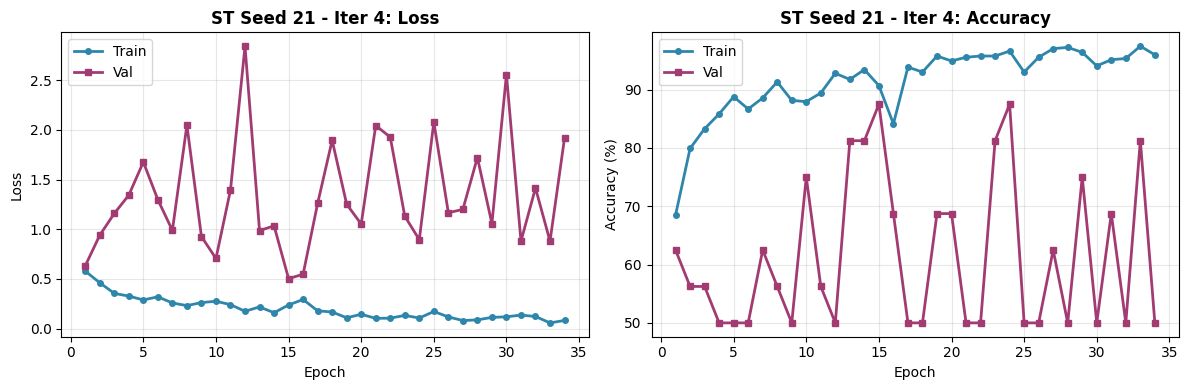

Evaluating Best Model (Seed 21)
Best Iteration: 4
Best Avg Acc: 78.43%
  Source: 69.37%
  Target: 87.50%
Loading model from: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90/seed_21/st_iter_4.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           69.37%      0.7500       82.26%       53.06%    1.2695
Lu (target domain)             87.50%      0.8571       75.00%      100.00%    0.8948
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 78.43%)


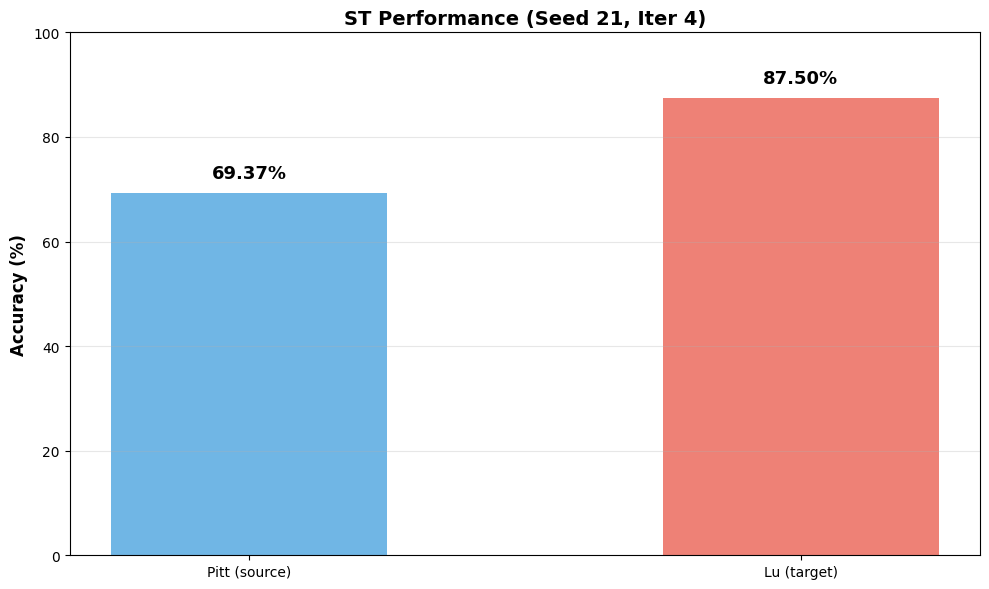

In [7]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    seed=21,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    manual_weight_control=CLASS_WEIGHT_CONTROL,
    manual_weight_dementia=CLASS_WEIGHT_DEMENTIA,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot its training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['target_val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model (function will load correct iteration checkpoint)
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 42


Self-Training: Seed 42
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch 1 - Training:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.716 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525


Epoch   2 | Train: 0.816 | Source Val: 0.613 | Target Val: 0.500 | Avg: 0.556


Epoch   3 | Train: 0.850 | Source Val: 0.541 | Target Val: 0.500 | Avg: 0.520


...

Epoch  13 | Train: 0.945 | Source Val: 0.622 | Target Val: 0.750 | Avg: 0.686


Epoch  14 | Train: 0.949 | Source Val: 0.640 | Target Val: 0.625 | Avg: 0.632


Epoch  15 | Train: 0.919 | Source Val: 0.676 | Target Val: 0.625 | Avg: 0.650


Epoch  16 | Train: 0.949 | Source Val: 0.703 | Target Val: 0.750 | Avg: 0.726


Epoch  17 | Train: 0.959 | Source Val: 0.613 | Target Val: 0.625 | Avg: 0.619
Early stopping at epoch 17 (best epoch: 7)

Iteration 5 Best Results (Epoch 7):
  Avg Acc: 75.31%
  Source Acc: 69.37% | F1: 0.6909
  Target Acc: 81.25% | F1: 0.8235

Self-Training Summary (Seed 42)
Best iteration: 4
Best avg accuracy: 76.21%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           72.18%      69.37%      75.00%     0.7385     0.7778        0
1           71.28%      67.57%      75.00%     0.7353     0.8000       26
2           74.41%      67.57%      81.25%     0.7273     0.8235       44
3           70.81%      60.36%      81.25%     0.6071     0.8235       46
4           76.21%      71.17%      81.25%     0.7576     0.8421       51
5           75.31%      69.37%      81.25%     0.6909     0.8235       52


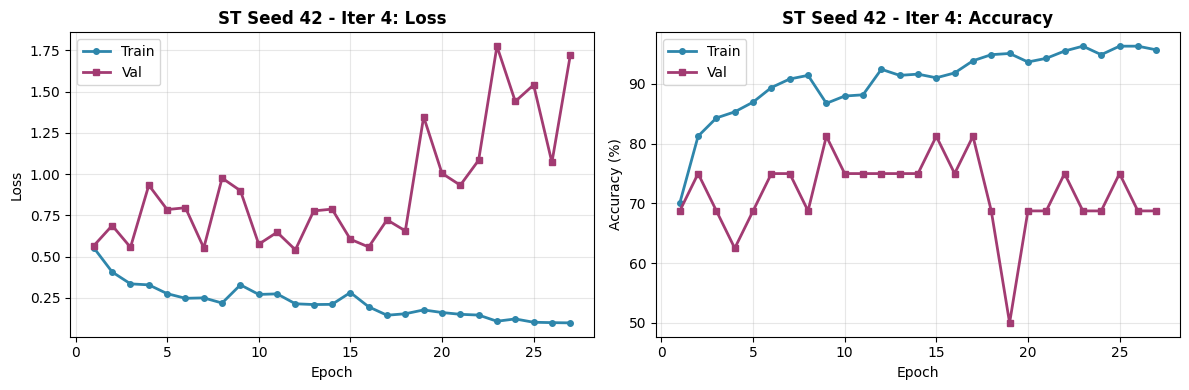

Evaluating Best Model (Seed 42)
Best Iteration: 4
Best Avg Acc: 76.21%
  Source: 71.17%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90/seed_42/st_iter_4.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           71.17%      0.7576       80.65%       59.18%    0.9163
Lu (target domain)             81.25%      0.8421      100.00%       62.50%    0.7232
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 76.21%)


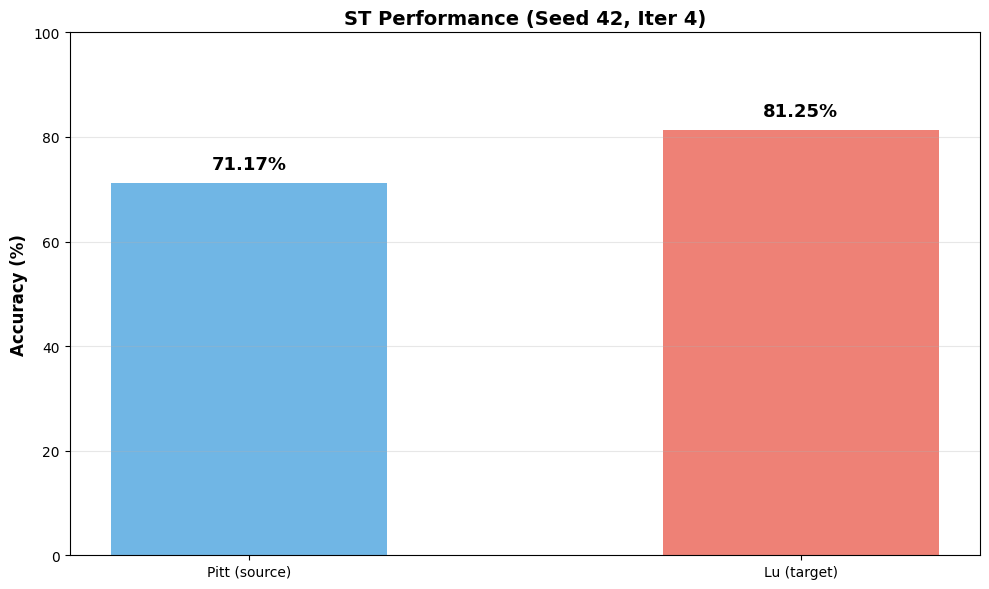

In [8]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    42, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 84


Self-Training: Seed 84
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.668 | Source Val: 0.514 | Target Val: 0.375 | Avg: 0.444


Epoch   2 | Train: 0.807 | Source Val: 0.595 | Target Val: 0.500 | Avg: 0.547


Epoch   3 | Train: 0.832 | Source Val: 0.622 | Target Val: 0.562 | Avg: 0.592


Epoch   4 | Train: 0.868 | Source Val: 0.667 | Target Val: 0.500 | Avg: 0.583


...

Epoch   8 | Train: 0.918 | Source Val: 0.658 | Target Val: 0.688 | Avg: 0.673


Epoch   9 | Train: 0.897 | Source Val: 0.577 | Target Val: 0.500 | Avg: 0.538


Epoch  10 | Train: 0.877 | Source Val: 0.631 | Target Val: 0.625 | Avg: 0.628


Epoch  11 | Train: 0.914 | Source Val: 0.658 | Target Val: 0.750 | Avg: 0.704


Epoch  12 | Train: 0.892 | Source Val: 0.676 | Target Val: 0.625 | Avg: 0.650
Early stopping at epoch 12 (best epoch: 2)

Iteration 5 Best Results (Epoch 2):
  Avg Acc: 74.41%
  Source Acc: 67.57% | F1: 0.7391
  Target Acc: 81.25% | F1: 0.8000

Self-Training Summary (Seed 84)
Best iteration: 4
Best avg accuracy: 75.28%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           62.36%      68.47%      56.25%     0.7619     0.6667        0
1           69.93%      64.86%      75.00%     0.6422     0.8000       35
2           64.56%      60.36%      68.75%     0.6071     0.7059       16
3           70.35%      59.46%      81.25%     0.6341     0.8000       25
4           75.28%      63.06%      87.50%     0.7211     0.8571       20
5           74.41%      67.57%      81.25%     0.7391     0.8000       24


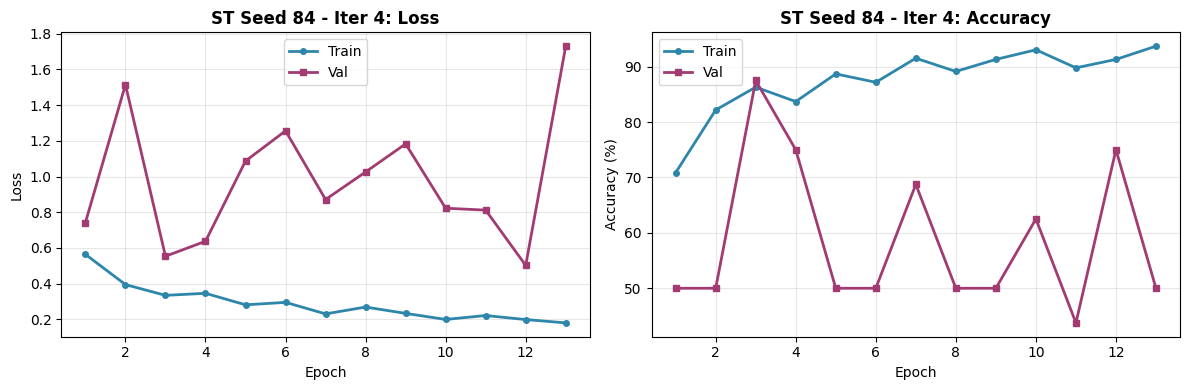

Evaluating Best Model (Seed 84)
Best Iteration: 4
Best Avg Acc: 75.28%
  Source: 63.06%
  Target: 87.50%
Loading model from: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90/seed_84/st_iter_4.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           63.06%      0.7211       85.48%       34.69%    0.9374
Lu (target domain)             87.50%      0.8571       75.00%      100.00%    0.5534
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 75.28%)


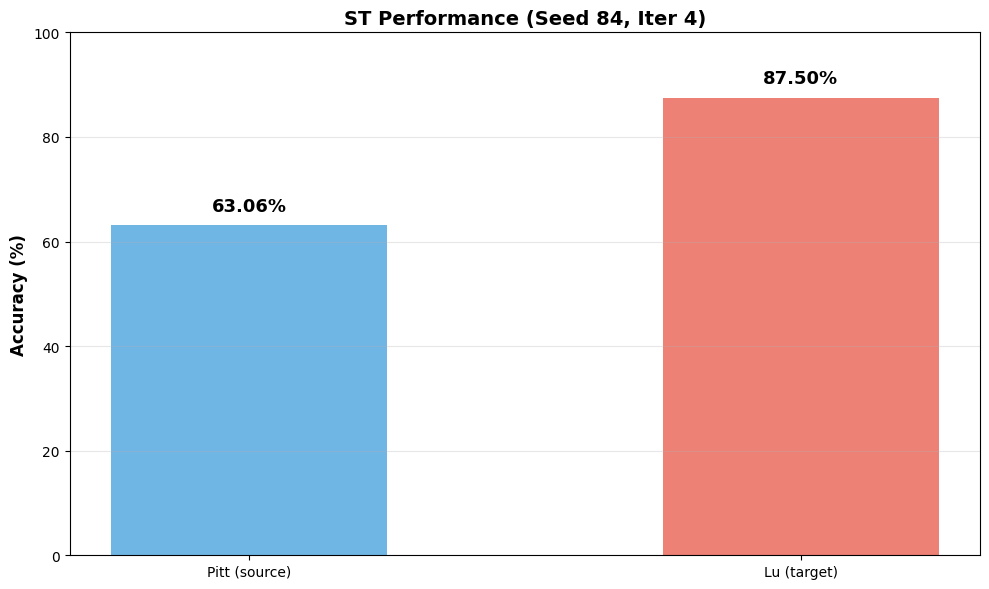

In [9]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    84, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 168


Self-Training: Seed 168
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.702 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch 2 - Training:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.791 | Source Val: 0.586 | Target Val: 0.562 | Avg: 0.574


Epoch   3 | Train: 0.845 | Source Val: 0.595 | Target Val: 0.500 | Avg: 0.547


...

Epoch  15 | Train: 0.938 | Source Val: 0.658 | Target Val: 0.812 | Avg: 0.735


Epoch  16 | Train: 0.938 | Source Val: 0.676 | Target Val: 0.688 | Avg: 0.682


Epoch  17 | Train: 0.908 | Source Val: 0.559 | Target Val: 0.688 | Avg: 0.623


Epoch  18 | Train: 0.895 | Source Val: 0.631 | Target Val: 0.750 | Avg: 0.690


Epoch  19 | Train: 0.934 | Source Val: 0.613 | Target Val: 0.562 | Avg: 0.588
Early stopping at epoch 19 (best epoch: 9)

Iteration 5 Best Results (Epoch 9):
  Avg Acc: 75.76%
  Source Acc: 70.27% | F1: 0.7481
  Target Acc: 81.25% | F1: 0.8000

Self-Training Summary (Seed 168)
Best iteration: 4
Best avg accuracy: 76.21%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           69.06%      69.37%      68.75%     0.7463     0.7368        0
1           70.81%      60.36%      81.25%     0.6207     0.8000       30
2           73.96%      66.67%      81.25%     0.6992     0.8000       24
3           75.31%      69.37%      81.25%     0.7302     0.8000       39
4           76.21%      71.17%      81.25%     0.7333     0.8000       43
5           75.76%      70.27%      81.25%     0.7481     0.8000       47


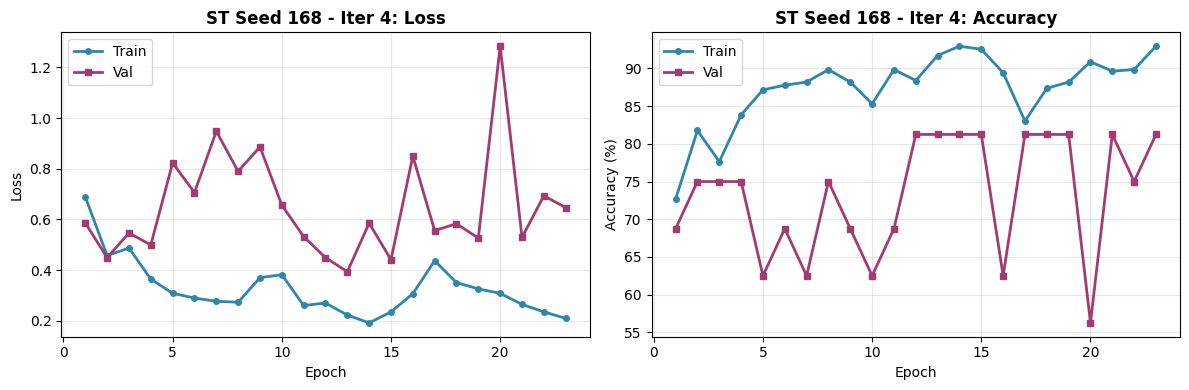

Evaluating Best Model (Seed 168)
Best Iteration: 4
Best Avg Acc: 76.21%
  Source: 71.17%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90/seed_168/st_iter_4.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           71.17%      0.7333       70.97%       71.43%    0.7570
Lu (target domain)             81.25%      0.8000       75.00%       87.50%    0.3934
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 76.21%)


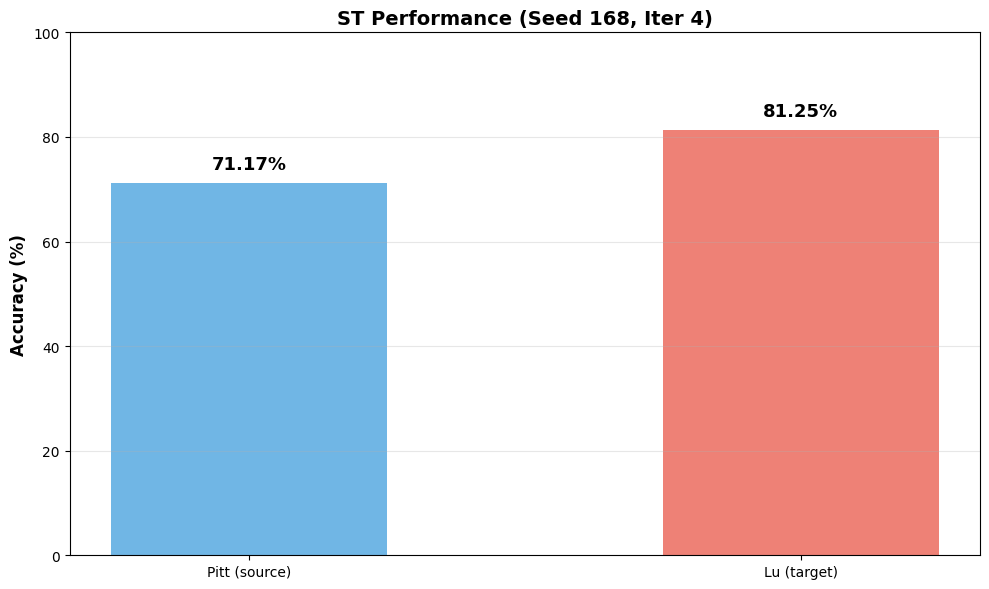

In [10]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    168, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 336


Self-Training: Seed 336
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch 1 - Training:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.680 | Source Val: 0.568 | Target Val: 0.500 | Avg: 0.534


Epoch   2 | Train: 0.795 | Source Val: 0.604 | Target Val: 0.500 | Avg: 0.552


Epoch   3 | Train: 0.834 | Source Val: 0.685 | Target Val: 0.688 | Avg: 0.686


...

Epoch   8 | Train: 0.916 | Source Val: 0.667 | Target Val: 0.750 | Avg: 0.708


Epoch   9 | Train: 0.899 | Source Val: 0.658 | Target Val: 0.688 | Avg: 0.673


Epoch  10 | Train: 0.927 | Source Val: 0.658 | Target Val: 0.688 | Avg: 0.673


Epoch  11 | Train: 0.927 | Source Val: 0.541 | Target Val: 0.375 | Avg: 0.458
Early stopping at epoch 11 (best epoch: 1)

Iteration 2 Best Results (Epoch 1):
  Avg Acc: 73.06%
  Source Acc: 64.86% | F1: 0.6486
  Target Acc: 81.25% | F1: 0.8000

Iteration 3: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (Seed 336)
Best iteration: 1
Best avg accuracy: 73.06%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           68.61%      68.47%      68.75%     0.7518     0.7059        0
1           73.06%      64.86%      81.25%     0.6214     0.8235       26
2           73.06%      64.86%      81.25%     0.6486     0.8000       37


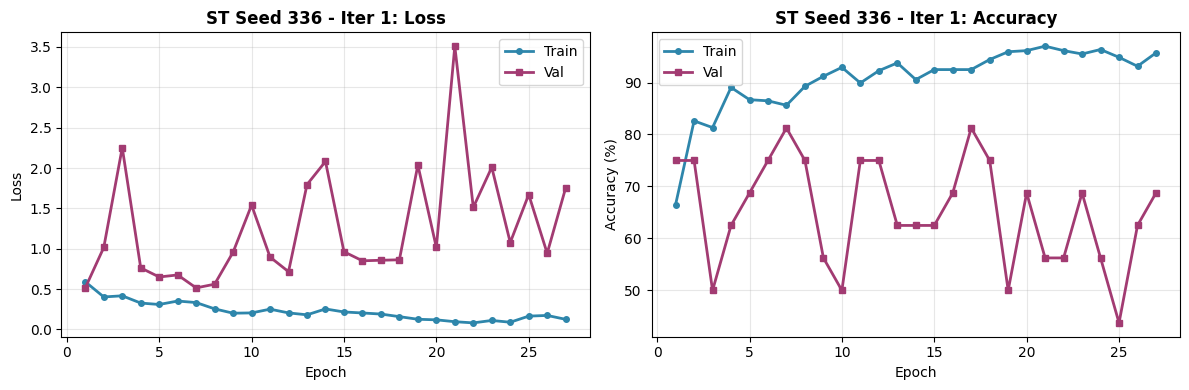

Evaluating Best Model (Seed 336)
Best Iteration: 1
Best Avg Acc: 73.06%
  Source: 64.86%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_Pitt_to_Lu_xlsr_t90/seed_336/st_iter_1.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           64.86%      0.6214       51.61%       81.63%    0.9225
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    0.8575
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 73.06%)


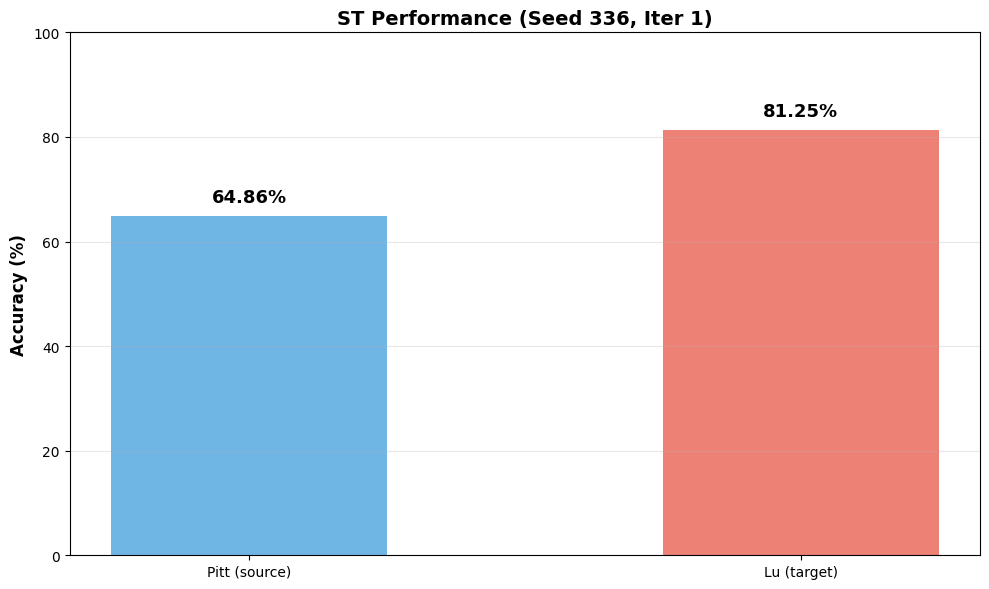

In [11]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st(
    336, source_train_dataset, target_train_dataset, source_val_loader, target_val_loader,
    MODEL_OUTPUT_DIR, device, MAX_ITERATIONS, CONFIDENCE_THRESHOLD, MIN_PSEUDO_SAMPLES,
    CLASS_WEIGHT_CONTROL, CLASS_WEIGHT_DEMENTIA, ST_WARMUP_EPOCHS, ST_MAX_EPOCHS,
)
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
plot_training_curves(all_histories[best_iter_idx]['epochs'], all_histories[best_iter_idx]['train_losses'],
                     all_histories[best_iter_idx]['target_val_losses'], all_histories[best_iter_idx]['train_accs'],
                     all_histories[best_iter_idx]['target_val_accs'], title_prefix=f'ST Seed {seed} - Iter {best_iter_idx}')

source_metrics, target_metrics = evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                                                            source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## 4 Summary and Visualization

In [12]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
Pitt (source domain)       67.93% ± 3.35%    0.7167 ± 0.0493      0.9605
Lu (target domain)         83.75% ± 3.06%    0.8360 ± 0.0218      0.6845
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       Pitt (source domain)           69.37%      0.7500       82.26%       53.06%    1.2695
         Lu (target domain)             87.50%      0.8571       75.00%      100.00%    0.8948
------------------------------------------------------------------------------------------
42       Pitt (source domain)           71.17%      0.7576       80.65%       59.18%    0.9163
         Lu (target do

In [ ]:
torch.cuda.empty_cache()

: 